**Long term memory**

In [1]:
#Import libraies
from langgraph.store.memory import InMemoryStore
import uuid

In [2]:
#In memory store to save data for current session 
in_memory_store = InMemoryStore()

In [3]:
user_id = "1"
current_namespace = (user_id , "food")
key =  str(uuid.uuid4)
value = {"dinner" : "butter chicken"}
in_memory_store.put(current_namespace , key , value)

In [4]:
datas = in_memory_store.search(current_namespace)

In [8]:
datas[0].dict()

{'namespace': ['1', 'food'],
 'key': '<function uuid4 at 0x00000238AABC5620>',
 'value': {'dinner': 'butter chicken'},
 'created_at': '2026-06-04T13:26:14.012302+00:00',
 'updated_at': '2026-06-04T13:26:14.012306+00:00',
 'score': None}

In [10]:
single_data =  in_memory_store.get(current_namespace , key)

In [13]:
single_data.dict()

{'namespace': ['1', 'food'],
 'key': '<function uuid4 at 0x00000238AABC5620>',
 'value': {'dinner': 'butter chicken'},
 'created_at': '2026-06-04T13:26:14.012302+00:00',
 'updated_at': '2026-06-04T13:26:14.012306+00:00'}

**LONG TERM MEMORU CHATBOT**

**Start -> Call Model -> Update Memory -> Stop**

In [ ]:
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph , START , END , MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver 
from langchain_core.messages import HumanMessage , AIMessage , SystemMessage




Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Hello! How can I help you today?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


LangSmithError: Failed to GET /sessions in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/sessions?limit=100&offset=0', '{"detail":"Forbidden"}')

In [54]:
#LLm 
# Create LLM 
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

In [55]:
#Function to chat with the model 
MODEL_CALL_PROMPT = """
    You are a helpfull assistance , You are a helpful assistant with memory that provides information about the user.
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}
"""

MODEL_MEMORY_WRITE_CALL = """
You are collecting information about the user to personalize your responses.
CURRENT USER INFORMATION:
{memory}
INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
- Personal details (name, location)
- Preferences (likes, dislikes)
- Interests and hobbies
- Past experiences
Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version
Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.
Based on the chat history below, please update the user information:
"""

def call_model(state : MessagesState , config : RunnableConfig , store : BaseStore):
    """Function to get the user id based on which it will take the memory and chat with the person"""
    #Get the User id 
    user_id =  config['configurable'].get("user_id")
    #Get the memory if avalibale based on the user id 
    current_namespace =  ('data' , user_id)
    memory =  store.get(current_namespace , 'memory')
    
    if memory:
        memory_content =  memory.value.get('memory_data')
    else :
        memory_content = "No memory till now"
    #Get the prompt for the updates 
    prompt =  MODEL_CALL_PROMPT.format(memory=memory_content)
    #Return the messages state as messages 
    response = llm.invoke([SystemMessage(content=prompt)] + state['messages'])

    return {"messages" : response}

def write_memory(state : MessagesState , config : RunnableConfig , store : BaseStore):
    """Function to get the user id and update the memory of the chat person """

    # Get the user id
    user_id = config['configurable'].get('user_id')
    # Get the memory i avaliable based on the user id 
    current_namespace = ("date" , user_id)
    # Memory based on the memory
    memory = store.get(current_namespace , 'memory')
    if memory:
        exciting_memory =  memory.value.get("memory_data")
    else:
        exciting_memory = "No previouse data found"
    # Prompt from the system prompt 
    system_prompt = MODEL_MEMORY_WRITE_CALL.format(memory = exciting_memory)
    # Respoonse from the llm 
    response = llm.invoke([SystemMessage(content=system_prompt)] + state['messages'])


    key=  'memory_data'
    # Update the store 
    store.put(current_namespace , "memory" , {key : response.content})


In [56]:
# Build the agent 
builder = StateGraph(MessagesState)
builder.add_node('call_model' ,call_model)
builder.add_node('write_memory' , write_memory)
builder.add_edge(START , 'call_model')
builder.add_edge('call_model' , 'write_memory')
builder.add_edge('write_memory' , END)

in_memory_store = InMemoryStore()
saver = MemorySaver()

agent =  builder.compile(checkpointer=saver , store=in_memory_store)

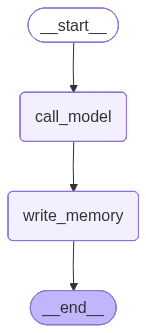

In [57]:
agent

In [58]:
config = {'configurable' :
          {
              "user_id"  : "1" ,
              "thread_id" : "1"
          }}

In [59]:
for steps in agent.stream({"messages" : "My name is puvith"} , config=config ,stream_mode='values'):
    print(steps['messages'][-1].pretty_print())

================================ Human Message =================================

My name is puvith
None
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Nice to meet you, Puvith! I have noted your name. How can I help you today?', 'extras': {'signature': 'EqYGCqMGAQw51sc4peJEVB36JXJLB93PsN2T/eY4AK4vR1yUBkfx4Zs0S30i+xEolfTcgIB5v2A5Bw5u3JKOt1h85+ALXm2j/IDEKTHO++VHlSh9gaziKt8JSku4SxGXFjKh8qWEYZdAF9hqsnHbbWCbD9KugeXznUIMFaGuaNcLPWR+Adh4YCn1hHzktR4wuSsK+pcpscUD+vJFC66tHr/lpOPgL9uUiR13yuYvz4MyqRlIGKXmPNmvHYNoMq4Gj21YE2CZc+OIzbC28EHAhfYflXrwN7ntWVEXHcgkn/ITNxvIz3zM2Uz3wrU+FLNL54HQTsEG6Gdj0sG0oDMuc8ylFcw6O+QGD02ZGiK8dJCLrphb0gWzY3FLvCy5lMpd/je/mQbSfzV8kh5EfDgbxBrVk5ZOMkPu2akD2I7qZXXrZR90eVQ4PYNS10bxyMoHnoGA0Pac3svMugn4N+mcW30a84JRklIldPwgkVou3aTRths42fI/6oJOTO5HxmDF6L1JyR/iW+tXzpB5KfWibqL++CA2pMJYywlwm08E6too5DVMC/0mc9P83aLO8IrnldmWvC7jghGru0TsdH3NR66BDSHTqPRe4IMs2T+s8wTA/fuh9NhS7ja8eS5TAMCPiRH9R5tJgbHHNhYMNUwA5zAoBKXMdn1UyZotWM7OH9b

In [24]:
config = {'configurable' :
          {
              "user_id"  : "1" ,
              "thread_id" : "2"
          }}

In [25]:
for steps in agent.stream({"messages" : "What is my name can uh can"} , config=config , stream_mode='values'):
    print(steps['messages'][-1].pretty_print())

================================ Human Message =================================

What is my name can uh can
None
================================== Ai Message ==================================

[{'type': 'text', 'text': "I don't know your name yet! My memory is currently empty, so I haven't had the chance to learn it.\n\nWhat is your name? If you tell me, I'll remember it for our future conversations.", 'extras': {'signature': 'EsEECr4EAQw51scyiHrJxMFQXJslKAtFzvNo9tefNjx2VOLxHfI9JE9BwSr0AxMvzKl8QuhRvkjX/sPoo/x7UPcRRacxheO31N5AAf1EGY6I2oGu3j8CbXuWDos9RJ4SXxHDpnA/MzSpce1qEcijuiQdbKBpY1NSK71cueSMCuRhYqYZ1j5OU5GvchIM+/hhSmkjITm7Ky65D5mBLAqU+4ZV4faXc/i9AvWAcYrwaGKgYELPHLe34SI0QM+O1Fj3bVoFhaKB4f1TNFcF/PcSsY/sVGXc/dNGcVDBMY8JclJDUJYVRiLUImC7AiI48pLrxIXNX/WjMGzKpnOL//sdrej8H0U9HJsKdnEeCj+4sRp7ocWGDE5VKPtnnSzuzQTyawx1vdOl3OcxKBgx35xlFJ1BBevxzjgccV9KjALk/kZXvDHr6Yq3C8H4YOpMKXv6HINnU93UjqCqsngBFpwz4jy6WaQO+sxjEBF4HLDi+214irhW1GF9D2lX6qFn8znnWpi1K0iO6xm6sHc3KUYXUpCJ45Z5/RFb9XQR0M99BJ0r+w18sSlqhj

In [35]:
current_state = agent.get_state(config=config)

In [36]:
print(current_state)

StateSnapshot(values={'messages': [HumanMessage(content='My name is puvith', additional_kwargs={}, response_metadata={}, id='46455ece-3310-47dc-8427-28c23d92a9da'), AIMessage(content=[{'type': 'text', 'text': 'Nice to meet you, Puvith! I have noted your name. \n\nHow can I help you today?', 'extras': {'signature': 'ErQFCrEFAQw51sfSsxtLk1xOKmUGaVMPFP+B8/8XVfNzEWUWVyjh/q0NdDmdlg8cOK6IUO02fuAvK3ZqyLSWS3IsO67TjxCxzoMJbssNolGYeaGrfLWeDZv30JVJHFfkCLxpQJ9DszC7e15WVZep/lcKMXoP+EpFLEL7T6CCDkt3xa+QfUDTaEC+GNsHs4Q0967fRhVmgo4s0EgNpj6zEX8TmdL5JWTxC2Jm1TXjozrH0W5ogERsP+tdYiPJn3yUpoIQQUvRh9k02mttTeMIXclBabnrVA3okrmgmIdrnfvcxcGdAvkB3/prlVhntTTSoaN7Nci73aI2fE7rC8x1j1A4ietfmwAZ3egRnLDAq04PtY6RPWDOZP0gk7a9Cg/XoczIOFbPIITst7DoLK4rGf34J+SyntJ3FoTAnZMDQxZ9V+DIGRaBelNR6+u4o+36oAE8l52MHkYfcv4vvH4JAlfppcGAwHKE4eUOb2m39RqNGSEqQ+pZxY7IHXnLDnCdfzG2yuAJjTt/wb+8CHqMAgRs4s45WOWx0+8dNdYSAS9UNV80D3i+YD5OhMCrD5R/vk6MeIuJzjg/8fVmSNOt8LlQIl46/y+pmfOcHzb60QrxU9Z2AeNMSEkJe2SKYAa8XA4sHWGUZslL1P5AaRHrI6e0OaHgInPUwyzRdk40Luz

In [34]:
for steps in agent.stream({"messages" : "What is my name can uh can"} , config=config , stream_mode='values'):
    print(steps['messages'][-1].pretty_print())

================================ Human Message =================================

What is my name can uh can
None
================================== Ai Message ==================================

[{'type': 'text', 'text': "Your name is **Puvith**. I've remembered it from our conversation! How can I help you today?", 'extras': {'signature': 'EqsFCqgFAQw51sdto6WrzX5C3r7bOz6hhNNsxsrb8j6zyTuzne0MIPWLVkYPvziKWSltj4mY/YUxa3O+ntL4bxs6aZAY/pI3p0rRKVufssoauxop0VhSvdlNd8ptCQyayVuy0C8IAIq2D+6zruIY+QwBQ36Rh7+fVZfmy6lnhwjDsiaghJuybcQEWbdcRFxmFgw+rBUsbbYTYaiekcxgAaY+7a8hKMnn9z8/CetDO6g3NF1ArHf0Hp8uPZbJgGZxnQGa1RleWqDgozx4HJQF9CvmJh4ZBZdl/LhdSJQ+sGE8sFm9MXCQKO/7QeKjovBoEk2ingRDlJ5OPgDY6fxnfRwX6gs7bYS8qHNcn9pkoP80WRL8k5UU0fbfFqfVZRtM28MmmwrSiWGIz6wX6U0XVP02BW6ScANB5FCTa0j8KB/jz8mdnI+2w2yGVpGwPlkdUjtvPWADLd6hsyY1fhS2nwqZ/aoS2W3I9LD0VWgnLNxdrCLlwij5+fZDEE+MAdg68hktPu1srvDCrU8WFUpMBIANtNdC72NMCr6dlOuKWiy2/XEM6VMfO61XibTl6pUj3paKXfyg/t8vUTeAoLRdeqUD2fNuGjPPF493cIIwcTPIBuZtY4oHyrLRO91hGeU2E7ithD9KHiD3hbkOM